# MSK MRI Dataset Diversity Montage

This notebook builds a publication-quality montage summarizing dataset diversity across anatomy and either
orientation or contrast. Each tile shows a representative RSS magnitude slice with a zoom-in inset.

**Figure goal**
- Rows: anatomy groups (e.g., KNEE, HIP, SPINE, SHOULDER, ANKLE, FOOT, PELVIS, LEG)
- Columns: either orientation {AX, SAG, COR} or contrast {T1, T2, PD, STIR}
- Each cell: one representative volume slice with per-tile normalization and a detail inset


## Configuration
Update the dataset paths and choose the column mode. The notebook builds a cached metadata index to keep
subsequent runs fast.


In [59]:
from __future__ import annotations

import json
import math
import os
import re
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Consistent, publication-friendly style (serif/"academic")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "mathtext.fontset": "stix",
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

# ---- Load cached header-derived records (generated elsewhere) ----
# We use these to compute per-(anatomy group, contrast/orientation) averages for the tile captions.
RECORDS_JSON_PATH = Path("cache/rss_intersection_records.json")
RSS_INTERSECTION_RECORDS: List[Dict[str, object]] = []
if RECORDS_JSON_PATH.exists():
    RSS_INTERSECTION_RECORDS = json.loads(RECORDS_JSON_PATH.read_text())
else:
    print(f"Warning: cached records JSON not found at {RECORDS_JSON_PATH}. Tiles will show filenames.")

In [60]:
# ---- Dataset configuration ----

# Instead of scanning the full H5 dataset, this notebook reads the PNG samples
# exported by `save_rss_intersections.ipynb`.
SAMPLES_ROOT = Path("../outputs/rss_intersections_samples")

# "orientation" or "contrast" - should match the folder under SAMPLES_ROOT
COLUMN_MODE = "orientation"

# Reproducible random sampling: one random PNG per (anatomy, column) tile
RANDOM_SEED = 48

# ---- Montage configuration ----
PERCENTILES = (1, 99)
ROI_MODE = "edge"  # "edge" or "center"
ROI_SIZE = 80

FIG_DPI = 200
FIG_TITLE = "MSK MRI Dataset Diversity"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Override selection (optional) ----
# TILE_OVERRIDES examples:
#   {("KNEE", "AX"): "00.png"} -> match by filename substring
#   {("KNEE", "AX"): 3} -> pick the 4th candidate when sorted
SELECT_INTERACTIVELY = False
MAX_CANDIDATES = 12
TILE_OVERRIDES = {}

# ---- Anatomy unification + ordering ----
# Mirror the unified anatomy buckets used in pie_anatomy_volume_distribution.ipynb
# so both figures report consistent groups.
#
# Unification rules:
#   ANKLE + FOOT + (LEG + SCAPULA from SCAPULA_RIBS_FEMUR) -> ANKLE+FOOT
#   ELBOW + WRIST (hand) -> ELBOW+HAND
#   PELVIS + HIP -> PELVIS+HIP
#
# We then plot exactly these 6 rows:
#   KNEE, SHOULDER, SPINE, PELVIS+HIP, ELBOW+HAND, ANKLE+FOOT

UNIFIED_ANATOMY_ORDER = ["KNEE", "SHOULDER", "SPINE", "PELVIS+HIP", "ELBOW+HAND", "ANKLE+FOOT"]
UNIFIED_ANATOMY_LABELS = {
    "KNEE": "Knee",
    "SHOULDER": "Shoulder",
    "SPINE": "Spine",
    "PELVIS+HIP": "Pelvic girdle",
    "ELBOW+HAND": "Upper extremity",
    "ANKLE+FOOT": "Lower extremity",
}

# Backwards-compat: keep these names so existing helper code doesn't need refactors.
ANATOMY_ORDER = list(UNIFIED_ANATOMY_ORDER)
ANATOMY_LABELS = dict(UNIFIED_ANATOMY_LABELS)
ALLOW_OTHER_ANATOMIES = False
KEEP_EMPTY_ROWS = False

ORIENTATION_ORDER = ["AX", "SAG", "COR"]
ORIENTATION_LABELS = {
    "AX": "Axial",
    "SAG": "Sagittal",
    "COR": "Coronal",
}

CONTRAST_ORDER = ["T1", "T2", "PD", "STIR"]
CONTRAST_LABELS = {
    "T1": "T1-weighted",
    "T2": "T2-weighted",
    "PD": "Proton density",
    "STIR": "STIR",
}

## Header parsing and grouping helpers
These functions parse ISMRMRD headers and map each file to anatomy, orientation, and contrast buckets.


In [61]:
import xml.etree.ElementTree as ET


def _to_str_from_dataset(ds: h5py.Dataset) -> str:
    # Try asstr (available in h5py>=3) for string datasets
    try:
        return ds.asstr()[()].strip()
    except Exception:
        pass
    # Raw read
    obj = ds[()]
    # If bytes-like directly
    if isinstance(obj, (bytes, bytearray)):
        return bytes(obj).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
    # If numpy scalar string/bytes
    if np.isscalar(obj):
        if isinstance(obj.item(), (bytes, bytearray)):
            return obj.item().replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        try:
            return str(obj.item())
        except Exception:
            pass
    # If numpy array of uint8/bytes
    if isinstance(obj, np.ndarray):
        if obj.dtype == np.uint8:
            return bytes(obj.tobytes()).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'S':  # fixed-width bytes strings
            try:
                joined = b"".join(obj.tolist())
            except Exception:
                joined = bytes(obj.tobytes())
            return joined.replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'U':  # unicode strings
            try:
                return "".join(obj.tolist()).strip()
            except Exception:
                return str(obj)
    # Fallback
    return str(obj)


def read_header_str_from_file(f: h5py.File) -> str:
    if "ismrmrd_header" not in f:
        return ""
    return _to_str_from_dataset(f["ismrmrd_header"]) or ""


def _strip_xml_namespaces(root: ET.Element) -> ET.Element:
    for elem in root.iter():
        if isinstance(elem.tag, str) and "}" in elem.tag:
            elem.tag = elem.tag.split("}", 1)[1]
        if elem.attrib:
            elem.attrib = {k.split("}", 1)[1] if "}" in k else k: v for k, v in elem.attrib.items()}
    return root


def _parse_xml(header_str: str) -> Optional[ET.Element]:
    if not header_str:
        return None
    try:
        root = ET.fromstring(header_str)
    except Exception:
        return None
    return _strip_xml_namespaces(root)


def _xml_find_text(root: ET.Element, path: List[str]) -> Optional[str]:
    node = root
    for tag in path:
        node = node.find(tag)
        if node is None:
            return None
    return node.text.strip() if node.text else None


def parse_user_param(header_str: str, target_name: str) -> Optional[str]:
    root = _parse_xml(header_str)
    if root is None:
        return None
    for up in root.findall(".//userParameterString"):
        name = up.findtext("name")
        if name == target_name:
            value = up.findtext("value")
            return value.strip() if value else None
    return None


def parse_acceleration(header_str: str) -> Optional[float]:
    root = _parse_xml(header_str)
    if root is None:
        return None
    acc = _xml_find_text(root, [
        "encoding",
        "parallelImaging",
        "accelerationFactor",
        "kspace_encoding_step_1",
    ])
    if acc is None:
        return None
    try:
        return float(acc)
    except Exception:
        return None


def parse_recon_space(header_str: str) -> Optional[Tuple[int, int]]:
    root = _parse_xml(header_str)
    if root is None:
        return None
    x = _xml_find_text(root, ["encoding", "reconSpace", "matrixSize", "x"])
    y = _xml_find_text(root, ["encoding", "reconSpace", "matrixSize", "y"])
    if not x or not y:
        return None
    try:
        return int(x), int(y)
    except Exception:
        return None


SCAN_CATEGORIES = {
    "SPINE": {
        "includes": [
            "L-SPINE", "LSPINE", "L SPINE",
            "C-SPINE", "CSPINE", "C SPINE",
            "T-SPINE", "T SPINE",
            "AX T2 T-SP", "AX T2 T-SP WARP", "TSPINE",
        ]
    },
    "KNEE": {"includes": ["LT KNEE", "RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER", "RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP", "RT HIP", "RT FAI HIP"]},
    "ANKLE": {"includes": ["LT ANKLE", "RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT", "RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG", "RT TIB-FIB"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS", "ATH PUBALGIA", "ATHLETIC PUBALGIA"]},
    "ELBOW": {"includes": ["LT ELBOW", "RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST", "RT WRIST", "LT THUMB", "RT THUMB", "RT HAND", "WRIST RT"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA", "RIBS", "LT FEMUR"]},
}

ANATOMY_MAP = {
    "LEG_TIBFIB": "LEG",
    "PELVIS_PUBALGIA": "PELVIS",
    "WRIST_HAND_THUMB": "WRIST",
    "SCAPULA_RIBS_FEMUR": "SCAPULA",
}


def infer_anatomy(study_desc: str, protocol_name: Optional[str] = None) -> str:
    text = (study_desc or "").upper()
    if not text and protocol_name:
        text = protocol_name.upper()
    for cat, info in SCAN_CATEGORIES.items():
        for inc in info["includes"]:
            if inc in text:
                return ANATOMY_MAP.get(cat, cat)
    return "OTHER"


def infer_orientation(proto: Optional[str]) -> Optional[str]:
    if not proto:
        return None
    name = proto.upper()
    if re.search(r"AX(IAL)", name) or "TRA" in name:
        return "AX"
    if re.search(r"SAG(ITTAL)", name):
        return "SAG"
    if re.search(r"COR(ONAL)", name):
        return "COR"
    return None


def infer_contrast(proto: Optional[str]) -> Optional[str]:
    if not proto:
        return None
    name = proto.upper()
    if "STIR" in name:
        return "STIR"
    if "PD" in name:
        return "PD"
    if "T2" in name:
        return "T2"
    if "T1" in name:
        return "T1"
    return None


def anatomy_unify(anat: str) -> str:
    """Unify anatomy labels to match pie_anatomy_volume_distribution.ipynb."""
    a = (anat or "").upper()
    # Merge: ankle+foot AND also leg+scapula into the same bucket
    if a in {"ANKLE", "FOOT", "LEG", "SCAPULA_RIBS_FEMUR", "SCAPULA"}:
        return "ANKLE+FOOT"
    if a in {"ELBOW", "WRIST", "WRIST_HAND_THUMB", "HAND"}:
        return "ELBOW+HAND"
    if a in {"PELVIS", "HIP", "PELVIS_PUBALGIA"}:
        return "PELVIS+HIP"
    return a


## Metadata extraction
The metadata index is built from file headers and shapes without loading full volumes.


In [62]:
from collections import Counter


def list_h5_files(dataset_dirs: Iterable[str], recursive: bool = True, max_files: Optional[int] = None) -> List[Path]:
    paths: List[Path] = []
    for d in dataset_dirs:
        if not d:
            continue
        root = Path(d)
        if not root.exists():
            continue
        if recursive:
            paths.extend(sorted(root.rglob("*.h5")))
        else:
            paths.extend(sorted(root.glob("*.h5")))
    if max_files is not None:
        paths = paths[:max_files]
    return paths


def extract_record(path: Path) -> Optional[Dict[str, object]]:
    with h5py.File(path, "r") as f:
        header_str = read_header_str_from_file(f)
        protocol = parse_user_param(header_str, "tProtocolName")
        study_desc = parse_user_param(header_str, "tStudyDescription") or ""

        orientation = infer_orientation(protocol or study_desc)
        contrast = infer_contrast(protocol)
        anatomy = infer_anatomy(study_desc, protocol)

        num_slices = None
        height = None
        width = None
        coil_count = None
        recon_width = None
        recon_height = None

        recon_space = parse_recon_space(header_str)
        if recon_space:
            recon_width, recon_height = recon_space

        if "kspace" in f:
            kshape = f["kspace"].shape
            if len(kshape) >= 3:
                num_slices = kshape[0]
                height = kshape[-2]
                width = kshape[-1]
                coil_count = kshape[1] if len(kshape) >= 4 else 1
        elif "reconstruction_rss" in f:
            rshape = f["reconstruction_rss"].shape
            if len(rshape) >= 2:
                num_slices = rshape[0] if len(rshape) == 3 else 1
                height = rshape[-2]
                width = rshape[-1]
        elif "reconstruction" in f:
            rshape = f["reconstruction"].shape
            if len(rshape) >= 2:
                num_slices = rshape[0] if len(rshape) == 3 else 1
                height = rshape[-2]
                width = rshape[-1]

        accel = parse_acceleration(header_str)

    return {
        "path": path,
        "fname": path.name,
        "protocol": protocol,
        "study_desc": study_desc,
        "anatomy": anatomy,
        "orientation": orientation,
        "contrast": contrast,
        "num_slices": num_slices,
        "height": height,
        "width": width,
        "recon_height": recon_height,
        "recon_width": recon_width,
        "coil_count": coil_count,
        "accel": accel,
    }


def _serialize_record(rec: Dict[str, object]) -> Dict[str, object]:
    out = dict(rec)
    out["path"] = str(out["path"])
    return out


def _deserialize_record(rec: Dict[str, object]) -> Dict[str, object]:
    out = dict(rec)
    out["path"] = Path(out["path"])
    return out


## Build metadata index


In [63]:
# Build a "records" list by reading the exported PNG sample folders.
# Expected layout:
#   outputs/rss_intersections_samples/<column_mode>/<ANATOMY>/<COL>/<pngs>.png

rng = np.random.default_rng(RANDOM_SEED)

if COLUMN_MODE not in {"orientation", "contrast"}:
    raise ValueError("COLUMN_MODE must be 'orientation' or 'contrast'")
col_key = "orientation" if COLUMN_MODE == "orientation" else "contrast"
col_order = ORIENTATION_ORDER if COLUMN_MODE == "orientation" else CONTRAST_ORDER

samples_mode_dir = SAMPLES_ROOT / COLUMN_MODE
if not samples_mode_dir.exists():
    raise FileNotFoundError(
        f"Samples folder not found: {samples_mode_dir}. "
        "Run save_rss_intersections.ipynb first or update SAMPLES_ROOT."
    )

records: List[Dict[str, object]] = []

anatomy_dirs = [p for p in samples_mode_dir.iterdir() if p.is_dir()]
for anat_dir in sorted(anatomy_dirs):
    anatomy_raw = anat_dir.name
    anatomy = anatomy_unify(anatomy_raw)
    for col in col_order:
        col_dir = anat_dir / col
        if not col_dir.exists():
            continue
        pngs = sorted(list(col_dir.glob("*.png")))
        if not pngs:
            continue
        chosen = pngs[int(rng.integers(0, len(pngs)))]
        records.append({
            "path": chosen,
            "fname": chosen.name,
            "anatomy": anatomy,
            col_key: col,
            # keep these keys so existing formatting code doesn't break
            "num_slices": None,
            "height": None,
            "width": None,
            "recon_height": None,
            "recon_width": None,
            "coil_count": None,
        })

print(f"Loaded {len(records)} sample PNG records from {samples_mode_dir}")
print("Anatomy counts:", Counter(r["anatomy"] for r in records))

Loaded 33 sample PNG records from ../outputs/rss_intersections_samples/orientation
Anatomy counts: Counter({'ANKLE+FOOT': 9, 'ELBOW+HAND': 6, 'PELVIS+HIP': 6, 'KNEE': 3, 'OTHER': 3, 'SHOULDER': 3, 'SPINE': 3})


## Montage helpers


In [64]:
from collections import defaultdict


def normalize_image(img: np.ndarray, percentiles: Tuple[float, float] = (1, 99)) -> np.ndarray:
    p1, p99 = np.nanpercentile(img, percentiles)
    if not np.isfinite(p1) or not np.isfinite(p99) or p1 == p99:
        return np.zeros_like(img, dtype=np.float32)
    img = np.clip(img, p1, p99)
    return (img - p1) / (p99 - p1)


def center_crop(img: np.ndarray, size: int) -> np.ndarray:
    h, w = img.shape
    size = min(size, h, w)
    y0 = (h - size) // 2
    x0 = (w - size) // 2
    return img[y0 : y0 + size, x0 : x0 + size]


def center_crop_to_shape(img: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    h, w = img.shape
    target_h = min(target_h, h)
    target_w = min(target_w, w)
    y0 = (h - target_h) // 2
    x0 = (w - target_w) // 2
    return img[y0 : y0 + target_h, x0 : x0 + target_w]


def crop_to_recon_space(img: np.ndarray, rec: Dict[str, object]) -> np.ndarray:
    rh = rec.get("recon_height")
    rw = rec.get("recon_width")
    if rh and rw:
        return center_crop_to_shape(img, int(rh), int(rw))
    return img


def make_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape
    size = min(h, w)
    return center_crop(img, size)


def edge_roi(img: np.ndarray, size: int) -> np.ndarray:
    h, w = img.shape
    size = min(size, h, w)
    if size <= 0:
        return img


    gx = np.abs(np.diff(img, axis=1, prepend=img[:, :1]))
    gy = np.abs(np.diff(img, axis=0, prepend=img[:1, :]))
    energy = gx + gy


    ii = energy.cumsum(axis=0).cumsum(axis=1)


    def window_sum(y0: int, x0: int) -> float:
        y1 = y0 + size - 1
        x1 = x0 + size - 1
        total = ii[y1, x1]
        if y0 > 0:
            total -= ii[y0 - 1, x1]
        if x0 > 0:
            total -= ii[y1, x0 - 1]
        if y0 > 0 and x0 > 0:
            total += ii[y0 - 1, x0 - 1]
        return float(total)


    stride = max(1, size // 8)
    best = (0, 0)
    best_val = -1.0
    for y0 in range(0, h - size + 1, stride):
        for x0 in range(0, w - size + 1, stride):
            val = window_sum(y0, x0)
            if val > best_val:
                best_val = val
                best = (y0, x0)


    y0, x0 = best
    return img[y0 : y0 + size, x0 : x0 + size]


def select_roi(img: np.ndarray, size: int, mode: str = "edge") -> np.ndarray:
    if mode == "center":
        return center_crop(img, size)
    return edge_roi(img, size)


def load_sample_png(path: Path) -> np.ndarray:
    """Load a saved sample PNG as float32 grayscale in [0, 1]."""
    img = plt.imread(path)
    if img.dtype != np.float32 and img.dtype != np.float64:
        img = img.astype(np.float32) / 255.0
    if img.ndim == 3:
        img = img[..., :3].mean(axis=-1)
    return img.astype(np.float32)


def get_col_info(column_mode: str) -> Tuple[str, List[str], Dict[str, str]]:
    if column_mode not in {"orientation", "contrast"}:
        raise ValueError("column_mode must be 'orientation' or 'contrast'")
    col_key = "orientation" if column_mode == "orientation" else "contrast"
    col_order = ORIENTATION_ORDER if column_mode == "orientation" else CONTRAST_ORDER
    col_labels = ORIENTATION_LABELS if column_mode == "orientation" else CONTRAST_LABELS
    return col_key, col_order, col_labels


def get_complete_anatomy_rows(records: List[Dict[str, object]], column_mode: str) -> List[str]:
    """Return anatomies that have *all* required columns for the selected mode.

    This prevents plotting incomplete rows (which would otherwise show N/A tiles and
    leave the viewer with the impression of a sparse montage).
    """
    col_key, col_order, _ = get_col_info(column_mode)
    required = set(col_order)
    by_anat: Dict[str, set] = defaultdict(set)
    for r in records:
        anat = r.get("anatomy")
        col = r.get(col_key)
        if isinstance(anat, str) and isinstance(col, str):
            by_anat[anat].add(col)
    return sorted([anat for anat, cols in by_anat.items() if required.issubset(cols)])


def get_row_order(records: List[Dict[str, object]], column_mode: str) -> List[str]:
    # Only keep anatomies that are complete across all columns (contrast/orientation).
    complete = set(get_complete_anatomy_rows(records, column_mode))
    if not complete:
        return []


    # Keep the configured order, but only for complete anatomies.
    # With unified anatomies enabled, this will typically yield exactly 6 rows.
    ordered = [a for a in ANATOMY_ORDER if a in complete]

    if not ALLOW_OTHER_ANATOMIES:
        return ordered

    other_rows = sorted([a for a in complete if a not in ANATOMY_ORDER])
    ordered += [a for a in other_rows if a not in ordered]
    return ordered


def rank_records(recs: List[Dict[str, object]]) -> List[Dict[str, object]]:
    # For PNG samples, keep deterministic ordering by filename
    return sorted(recs, key=lambda r: str(r.get("path", "")))


def select_representative_record(recs: List[Dict[str, object]]) -> Dict[str, object]:
    ranked = rank_records(recs)
    return ranked[0]


def resolve_override_record(
    group: List[Dict[str, object]],
    override: Optional[object],
 ) -> Optional[Dict[str, object]]:
    if override is None:
        return None
    if isinstance(override, int):
        ranked = rank_records(group)
        idx = max(0, min(override, len(ranked) - 1))
        return ranked[idx]
    if isinstance(override, str):
        key = override.lower()
        for rec in group:
            if key in rec.get("fname", "").lower() or key in str(rec.get("path", "")).lower():
                return rec
    if isinstance(override, Path):
        for rec in group:
            if rec.get("path") == override:
                return rec
    return None


def select_record_for_tile(
    group: List[Dict[str, object]],
    override: Optional[object] = None,
 ) -> Dict[str, object]:
    resolved = resolve_override_record(group, override)
    if resolved is not None:
        return resolved
    return select_representative_record(group)


def _fmt_int(x: Optional[float]) -> str:
    if x is None:
        return "?"
    try:
        return str(int(round(float(x))))
    except Exception:
        return "?"


def _as_float(x: object) -> Optional[float]:
    if isinstance(x, (int, float)):
        return float(x)
    return None


def _compute_tile_caption_stats(
    rss_records: List[Dict[str, object]],
    column_mode: str,
) -> Dict[Tuple[str, str], Dict[str, float]]:
    """Aggregate per-(unified anatomy, column) averages from cached records JSON."""
    out: Dict[Tuple[str, str], Dict[str, float]] = {}
    sums: Dict[Tuple[str, str], Dict[str, float]] = defaultdict(lambda: defaultdict(float))
    counts: Dict[Tuple[str, str], int] = defaultdict(int)

    col_key = "contrast" if column_mode == "contrast" else "orientation"
    for r in rss_records:
        if not isinstance(r, dict):
            continue
        anat = anatomy_unify(str(r.get("anatomy", "")))
        col = r.get(col_key)
        if not isinstance(col, str) or not col:
            continue

        h = _as_float(r.get("height"))
        w = _as_float(r.get("width"))
        c = _as_float(r.get("coil_count"))
        s = _as_float(r.get("num_slices"))
        if h is None or w is None or c is None or s is None:
            continue

        key = (anat, col)
        sums[key]["height"] += h
        sums[key]["width"] += w
        sums[key]["coil_count"] += c
        sums[key]["num_slices"] += s
        counts[key] += 1

    for key, n in counts.items():
        if n <= 0:
            continue
        out[key] = {
            "avg_height": sums[key]["height"] / n,
            "avg_width": sums[key]["width"] / n,
            "avg_coils": sums[key]["coil_count"] / n,
            "avg_slices": sums[key]["num_slices"] / n,
            "n_volumes": float(n),
        }
    return out


TILE_CAPTION_STATS = _compute_tile_caption_stats(RSS_INTERSECTION_RECORDS, column_mode=COLUMN_MODE)


def format_tile_text(column_mode: str, anatomy: str, col_value: str, fallback: str = "") -> str:
    # Captions are based on cached header-derived records, aggregated per anatomy group
    # and per column value (contrast/orientation).
    key = (anatomy_unify(anatomy), str(col_value))
    stats = TILE_CAPTION_STATS.get(key)
    if not stats:
        return fallback
    h = _fmt_int(stats.get("avg_height"))
    w = _fmt_int(stats.get("avg_width"))
    n_coils = _fmt_int(stats.get("avg_coils"))
    n_slices = _fmt_int(stats.get("avg_slices"))
    # Keep it short so it fits in the tile.
    return f"{h}×{w}, coils≈{n_coils}, slices≈{n_slices}"


def _hex_to_rgb01(hex_color: str) -> Tuple[float, float, float]:
    s = hex_color.lstrip("#")
    return (int(s[0:2], 16) / 255.0, int(s[2:4], 16) / 255.0, int(s[4:6], 16) / 255.0)


def _blend(rgb: Tuple[float, float, float], alpha: float, background: Tuple[float, float, float] = (1.0, 1.0, 1.0)) -> Tuple[float, float, float]:
    # (1-alpha)*background + alpha*rgb
    return tuple((1 - alpha) * b + alpha * c for c, b in zip(rgb, background))


def get_inset_border_color(anatomy: str, col_value: str, col_order: List[str]) -> Tuple[float, float, float]:
    """Each anatomy gets a base color; each column gets a lighter/darker shade of it."""
    # Colorblind-friendly-ish base palette
    base_hex = {
        "KNEE": "#1f77b4",      # blue
        "PELVIS+HIP": "#ff7f0e",       # orange
        "SPINE": "#2ca02c",     # green
        "SHOULDER": "#d62728",  # red
        "ANKLE+FOOT": "#9467bd",     # purple
        "PELVIS": "#e377c2",    # pink
        "WRIST": "#bcbd22",     # olive
        "ELBOW+HAND": "#17becf",     # cyan
    }

    base = _hex_to_rgb01(base_hex.get(anatomy, base_hex["SCAPULA"]))
    try:
        j = col_order.index(col_value)
        denom = max(1, len(col_order) - 1)
        t = j / denom
    except ValueError:
        t = 0.5
    # Shade: vary alpha from 0.45 (light) -> 0.95 (dark) across columns
    alpha = 0.45 + 0.50 * float(t)
    return _blend(base, alpha, background=(1.0, 1.0, 1.0))


def preview_candidates(
    recs: List[Dict[str, object]],
    percentiles: Tuple[float, float] = (1, 99),
    max_show: int = 6,
 ):
    if not recs:
        print("No candidates to preview.")
        return
    show = recs[:max_show]
    fig, axes = plt.subplots(1, len(show), figsize=(len(show) * 2.2, 2.2), dpi=120)
    axes = np.atleast_1d(axes)
    for idx, (ax, rec) in enumerate(zip(axes, show)):
        img = load_sample_png(Path(rec["path"]))
        img = make_square(img)
        img = normalize_image(img, percentiles)
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(str(idx), fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()


def make_montage(
    records: List[Dict[str, object]],
    column_mode: str,
    percentiles: Tuple[float, float] = (1, 99),
    roi_mode: str = "edge",
    roi_size: int = 80,
    tile_overrides: Optional[Dict[Tuple[str, str], object]] = None,
 ) -> Tuple[plt.Figure, np.ndarray]:
    col_key, col_order, col_labels = get_col_info(column_mode)
    row_order = get_row_order(records, column_mode)
    if not row_order:
        raise ValueError(
            "No complete anatomy rows found: every anatomy is missing at least one "
            "required contrast/orientation. Either export more samples or switch COLUMN_MODE."
        )


    nrows = len(row_order)
    ncols = len(col_order)


    tile_w, tile_h = 2.3, 2.3
    fig_w = max(6.0, ncols * tile_w + 1.0)
    fig_h = max(6.0, nrows * tile_h + 1.0)


    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=FIG_DPI)
    axes = np.atleast_2d(axes)


    for i, row in enumerate(row_order):
        for j, col in enumerate(col_order):
            ax = axes[i, j]
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_edgecolor("0.6")


            group = [r for r in records if r["anatomy"] == row and r.get(col_key) == col]
            # With row filtering, this should never be empty, but keep a safe fallback.
            if not group:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=10, color="0.45")
            else:
                override = None
                if tile_overrides:
                    override = tile_overrides.get((row, col))
                rec = select_record_for_tile(group, override=override)
                img = load_sample_png(Path(rec["path"]))
                img = make_square(img)
                img = normalize_image(img, percentiles)
                ax.imshow(img, cmap="gray", vmin=0, vmax=1)


                roi = select_roi(img, roi_size, mode=roi_mode)
                iax = inset_axes(ax, width="33%", height="33%", loc="upper right", borderpad=0.2)
                iax.imshow(roi, cmap="gray", vmin=0, vmax=1)
                iax.set_xticks([])
                iax.set_yticks([])


                inset_color = get_inset_border_color(row, col, col_order)
                for spine in iax.spines.values():
                    spine.set_linewidth(1.2)
                    spine.set_edgecolor(inset_color)


                # Replace filename subtitle with intersection stats from JSON (fallback to filename).
                fallback = rec.get("fname", "") or ""
                tile_text = format_tile_text(column_mode, row, col, fallback=fallback)
                if tile_text:
                    ax.text(
                        0.02,
                        0.02,
                        tile_text,
                        transform=ax.transAxes,
                        ha="left",
                        va="bottom",
                        fontsize=8,
                        color="white",
                        bbox=dict(boxstyle="round,pad=0.22", fc="black", alpha=0.35, lw=0),
                    )


            if i == 0:
                ax.set_title(col_labels.get(col, col))
            if j == 0:
                label = ANATOMY_LABELS.get(row, row)
                ax.set_ylabel(label, rotation=90, ha="center", va="center", labelpad=12)


    fig.subplots_adjust(left=0.12, right=0.99, top=0.95, bottom=0.04, wspace=0.02, hspace=0.02)
    return fig, axes

## Optional: override tiles


In [65]:
tile_overrides = dict(TILE_OVERRIDES)
if SELECT_INTERACTIVELY:
    tile_overrides.update(
        interactive_override(
            records,
            column_mode=COLUMN_MODE,
            max_candidates=MAX_CANDIDATES,
        )
    )


## Create the montage


KeyError: 'SCAPULA'

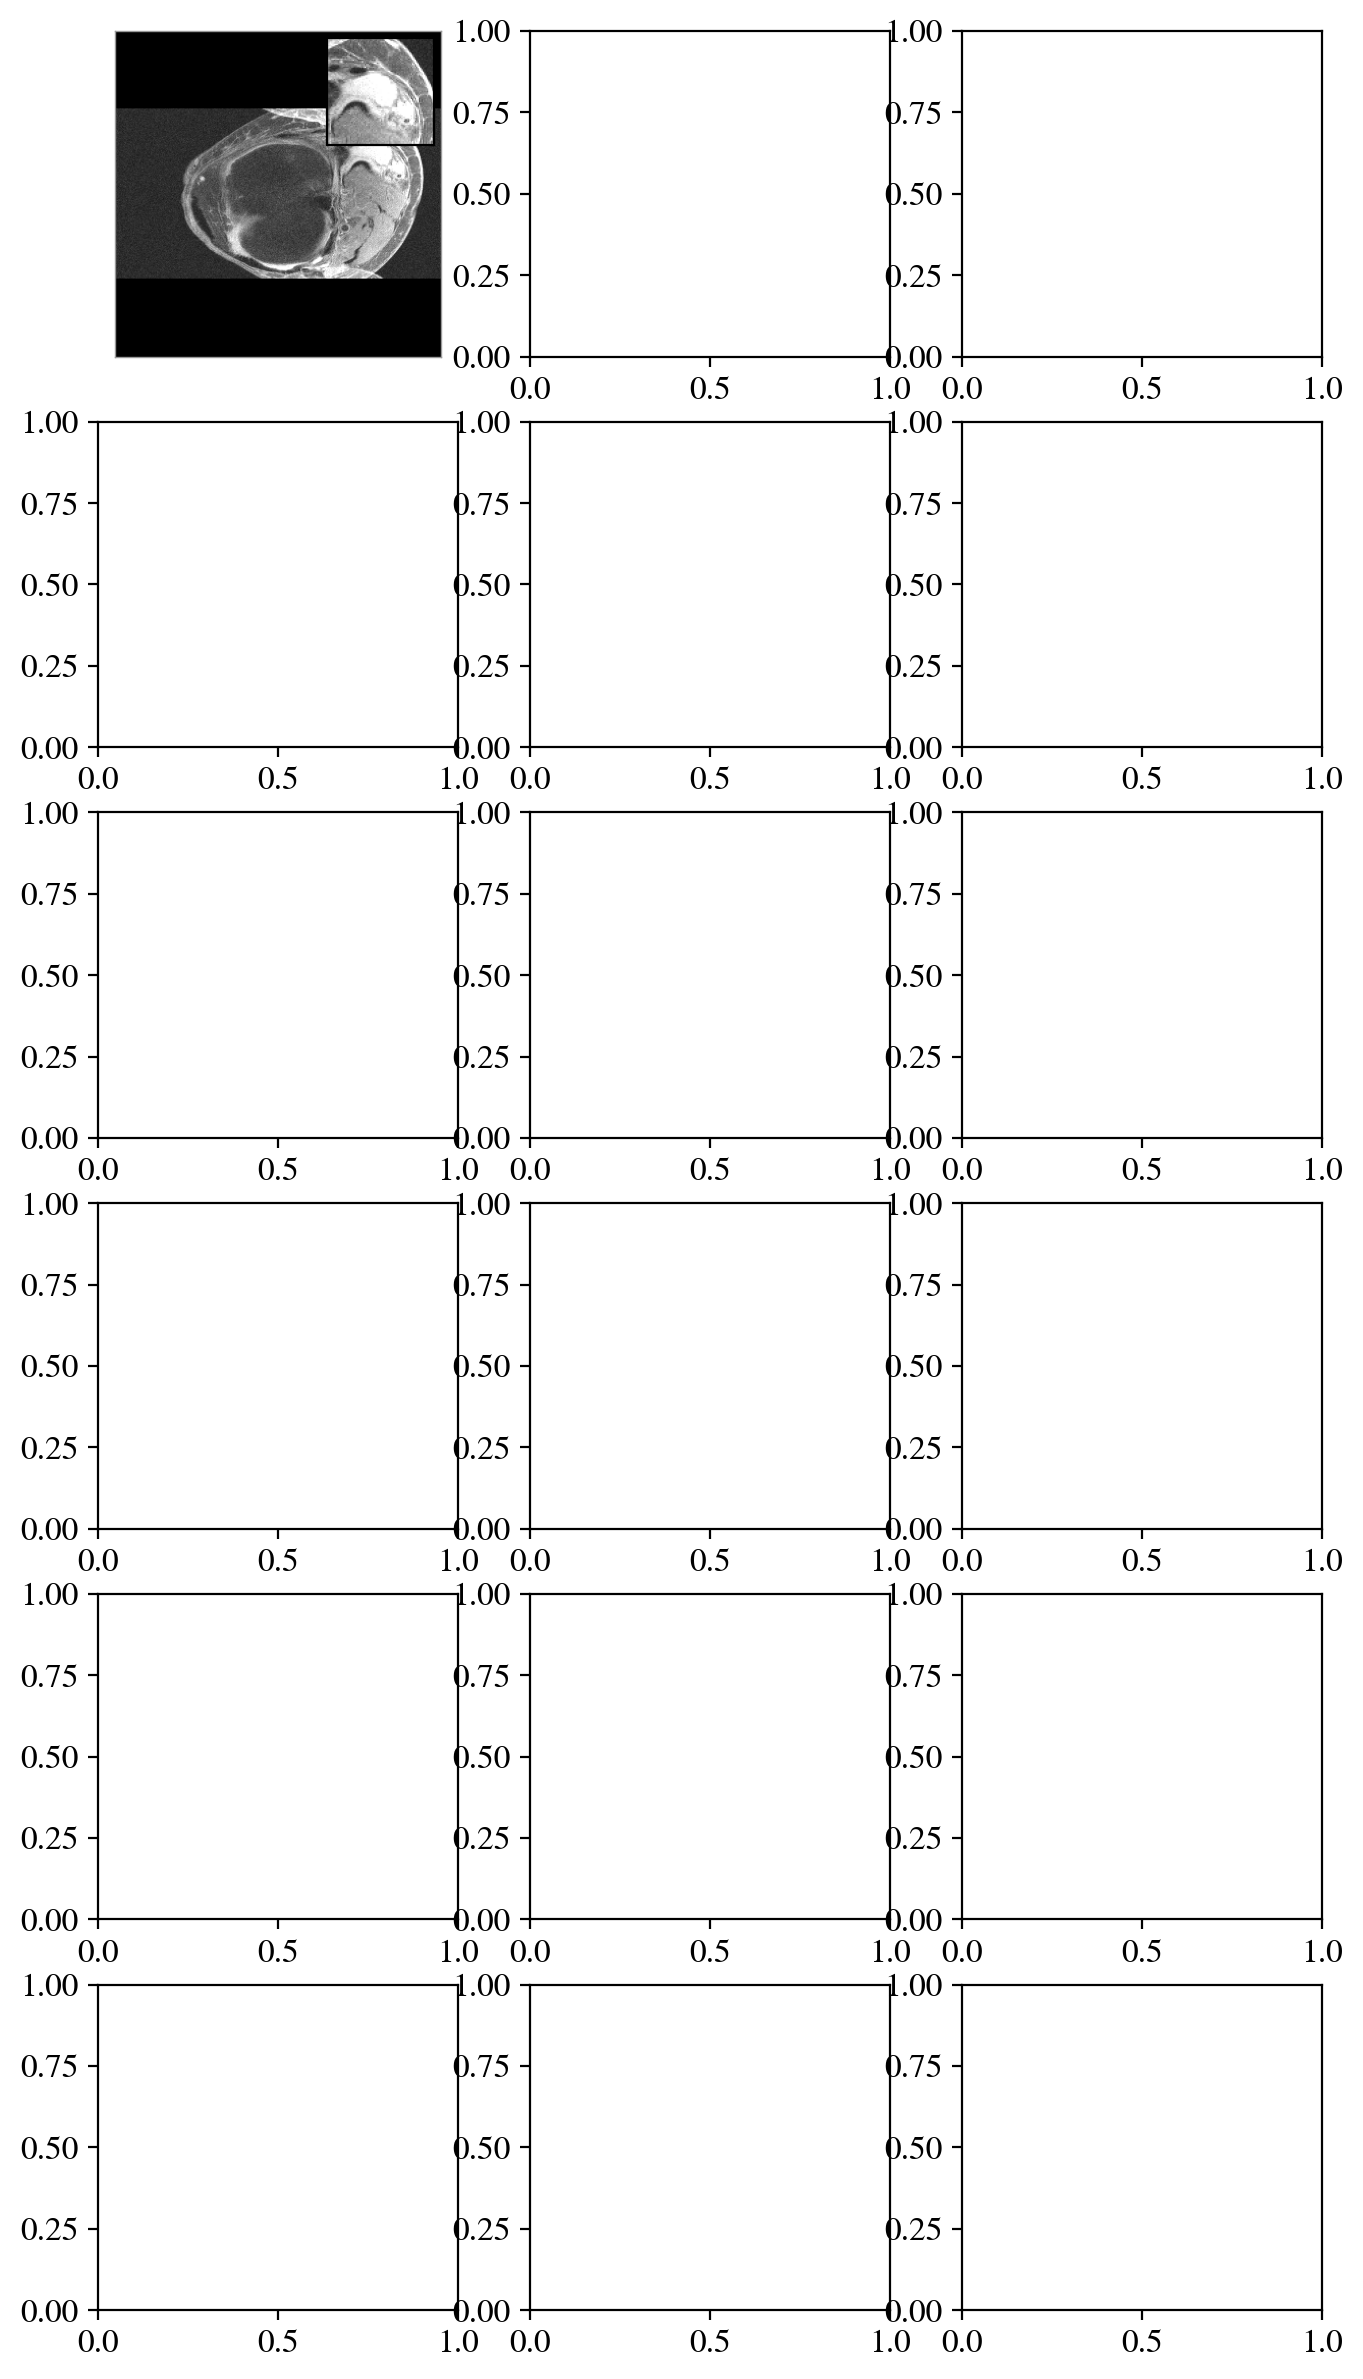

In [66]:
# If you skipped the optional override step, fall back to the configured defaults.
try:
    tile_overrides
except NameError:
    tile_overrides = dict(TILE_OVERRIDES)

fig, axes = make_montage(
    records,
    column_mode=COLUMN_MODE,
    percentiles=PERCENTILES,
    roi_mode=ROI_MODE,
    roi_size=ROI_SIZE,
    tile_overrides=tile_overrides,
 )

out_path = OUTPUT_DIR / f"msk_diversity_montage_{COLUMN_MODE}.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()